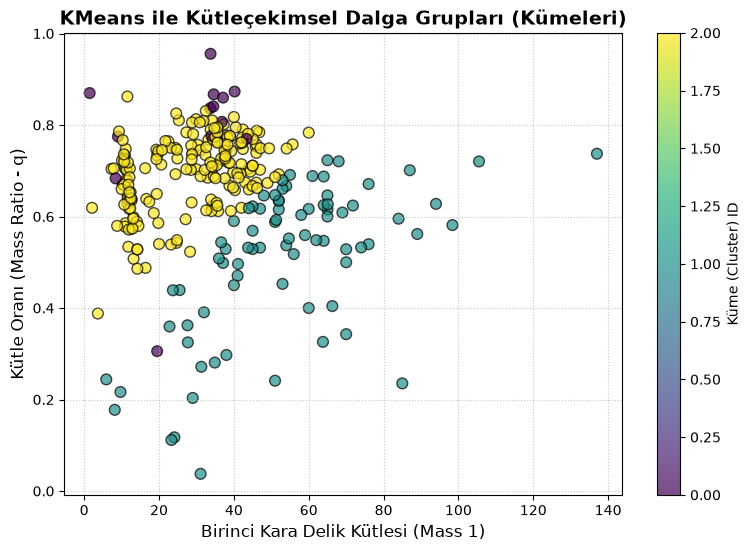

         mass_1_source  mass_ratio  network_matched_filter_snr
cluster                                                       
0            28.187692    0.786144                   35.053846
1            53.675875    0.509761                   11.246250
2            28.158201    0.696603                   11.998942


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('gw_data.csv')
df['mass_ratio'] = df['mass_2_source'] / df['mass_1_source']
# 1. Kullanacağımız verileri seçelim ve boşlukları temizleyelim
cluster_sutunlari = ['mass_1_source', 'mass_ratio', 'network_matched_filter_snr']
df_cluster = df[cluster_sutunlari].dropna()

# 2. Makine öğrenmesinde ölçeklendirme (Scaling) çok önemlidir (Farklı birimdeki verileri eşitlemek için)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

# 3. KMeans Modelini Kurma (Örneğin evrendeki kara delikleri 3 farklı gruba/türe ayıralım)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(df_scaled)

# 4. Sonuçları Görselleştirme
plt.figure(figsize=(9, 6))
scatter = plt.scatter(df_cluster['mass_1_source'], df_cluster['mass_ratio'], 
                      c=df_cluster['cluster'], cmap='viridis', alpha=0.7, s=60, edgecolors='black')

plt.xlabel('Birinci Kara Delik Kütlesi (Mass 1)', fontsize=12)
plt.ylabel('Kütle Oranı (Mass Ratio - q)', fontsize=12)
plt.title('KMeans ile Kütleçekimsel Dalga Grupları (Kümeleri)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Küme (Cluster) ID')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# Her kümede kaç tane olay var ve ortalamaları ne?
print(df_cluster.groupby('cluster').mean())